## Generate Ensemble Result

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
from collections import Counter

files = [
    "/gpt5.2et_RAG.csv",
    "/gpt5.2st_CoT_One.csv",
    "/gpt5.1st_Persona.csv"
]

dfs = []
for file in files:
    try:
        df = pd.read_table(file, sep=";")
    except Exception:
        df = pd.read_csv(file)
    dfs.append(df)


def majority_vote_labels(*labels, min_votes=2):
    """
    labels: "2,3" 같은 문자열 여러 개
    min_votes: 최소 몇 표 이상 받아야 채택할지 (3개 모델이면 2가 합리적)
    """
    all_labels = []

    for l in labels:
        if pd.isna(l):
            continue
        all_labels.extend(map(int, str(l).split(",")))

    if len(all_labels) == 0:
        return np.nan

    counter = Counter(all_labels)
    max_count = max(counter.values())

    # 최소 표 수 조건 + 최빈값
    voted = sorted([
        label for label, cnt in counter.items()
        if cnt == max_count and cnt >= min_votes
    ])

    if not voted:
        return np.nan

    return ",".join(map(str, voted))


base_df = dfs[0].copy()

base_df["voted_label"] = [
    majority_vote_labels(*(df.loc[i, "label"] for df in dfs))
    for i in base_df.index
]

base_df.head(10)

base_df[['comments','voted_label']].to_csv("/ensemble_result_v2.csv", index=False, index_label=False)
nan_rows = base_df[base_df["voted_label"].isna()]
nan_rows[['comments','voted_label']].to_csv("/ensemble_nan_votednsemble_result_v2.csv_labels_v2.csv", index=False, index_label=False)

#fileName = files[0]
#base_df[['comments','label']].to_csv(fileName.replace(".csv", "_ensemble_result_v2.csv"), index=False)
#nan_rows = base_df[base_df["label"].isna()]
#nan_rows[['comments','label']].to_csv(fileName.replace(".csv", "_ensemble_nan_voted_labels.csv"), index=False)


In [ ]:
base_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23078 entries, 0 to 23077
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   comments     23078 non-null  object
 1   label        23078 non-null  object
 2   voted_label  22905 non-null  object
dtypes: object(3)
memory usage: 541.0+ KB


# Heatmap - Accuracy

Alignment used per model:
 - gemini2.5-flash_RAG: ('text', '_join_text')
 - gemini2.5-flash_CoT_One: ('text', '_join_text')
 - gpt5.2et_Persona: ('text', '_join_text')
 - ensemble_result: ('text', '_join_text')


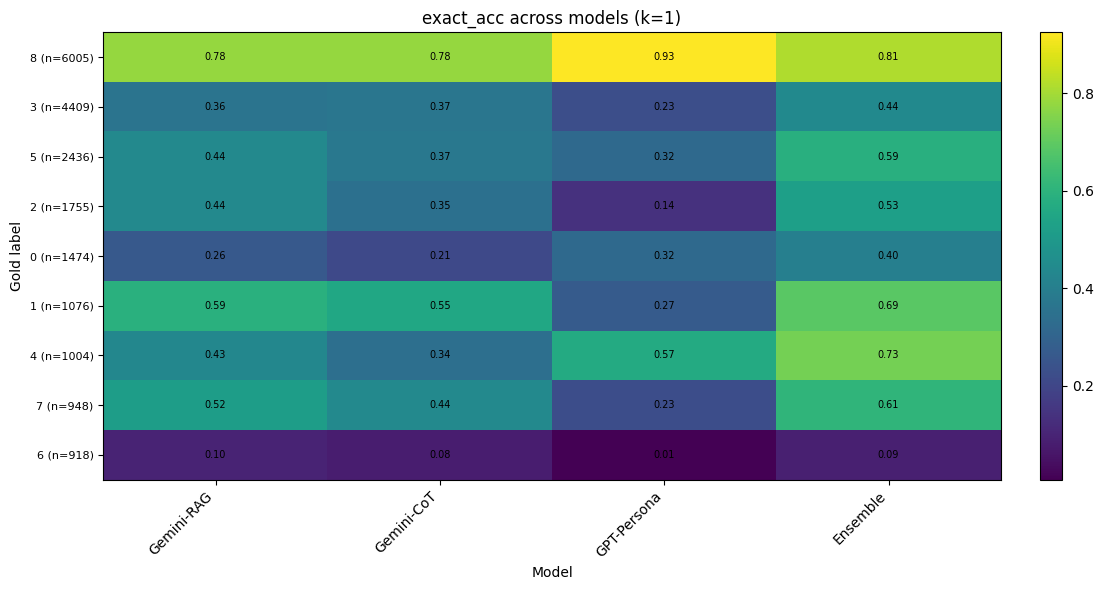

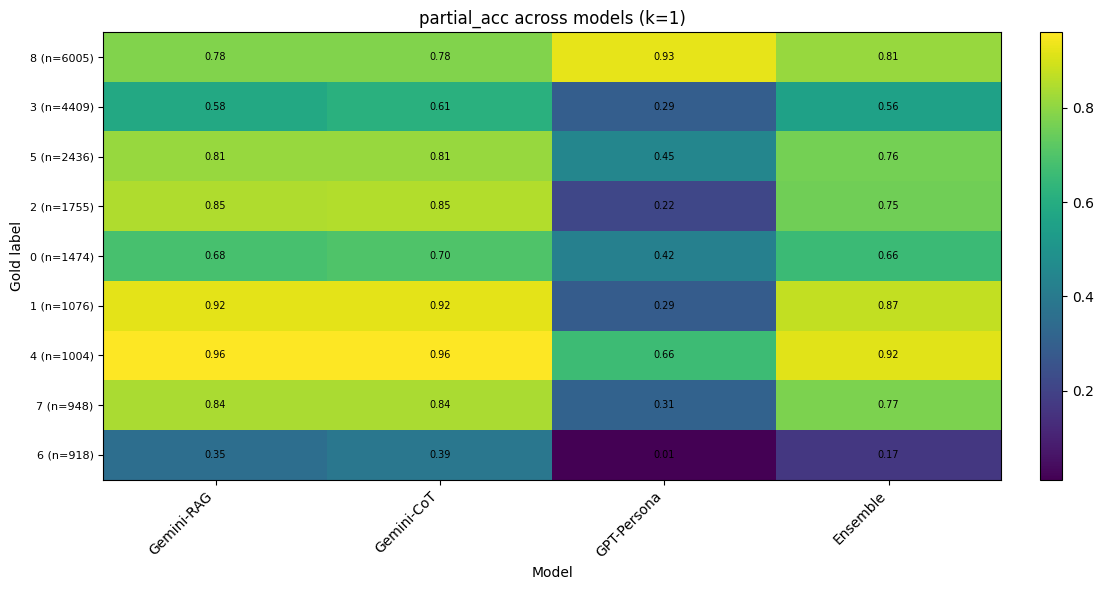

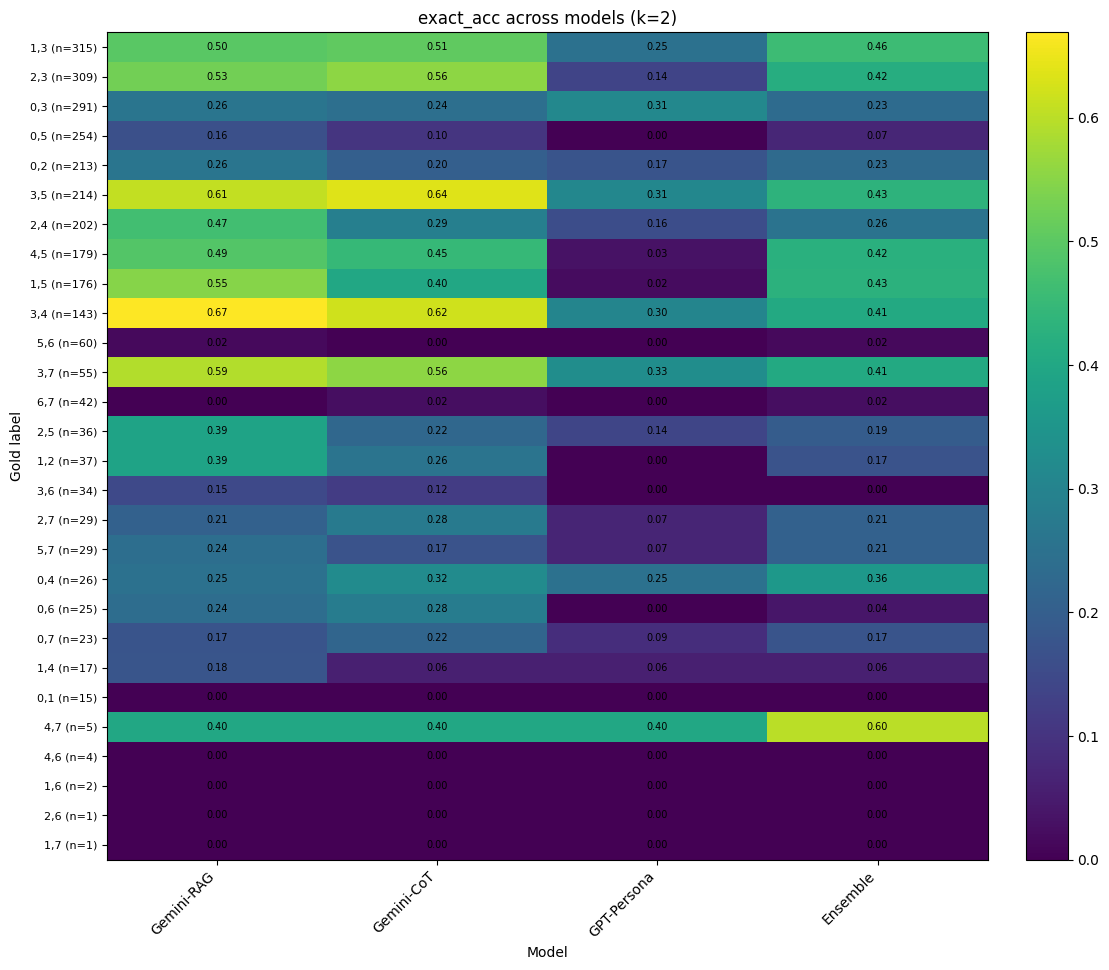

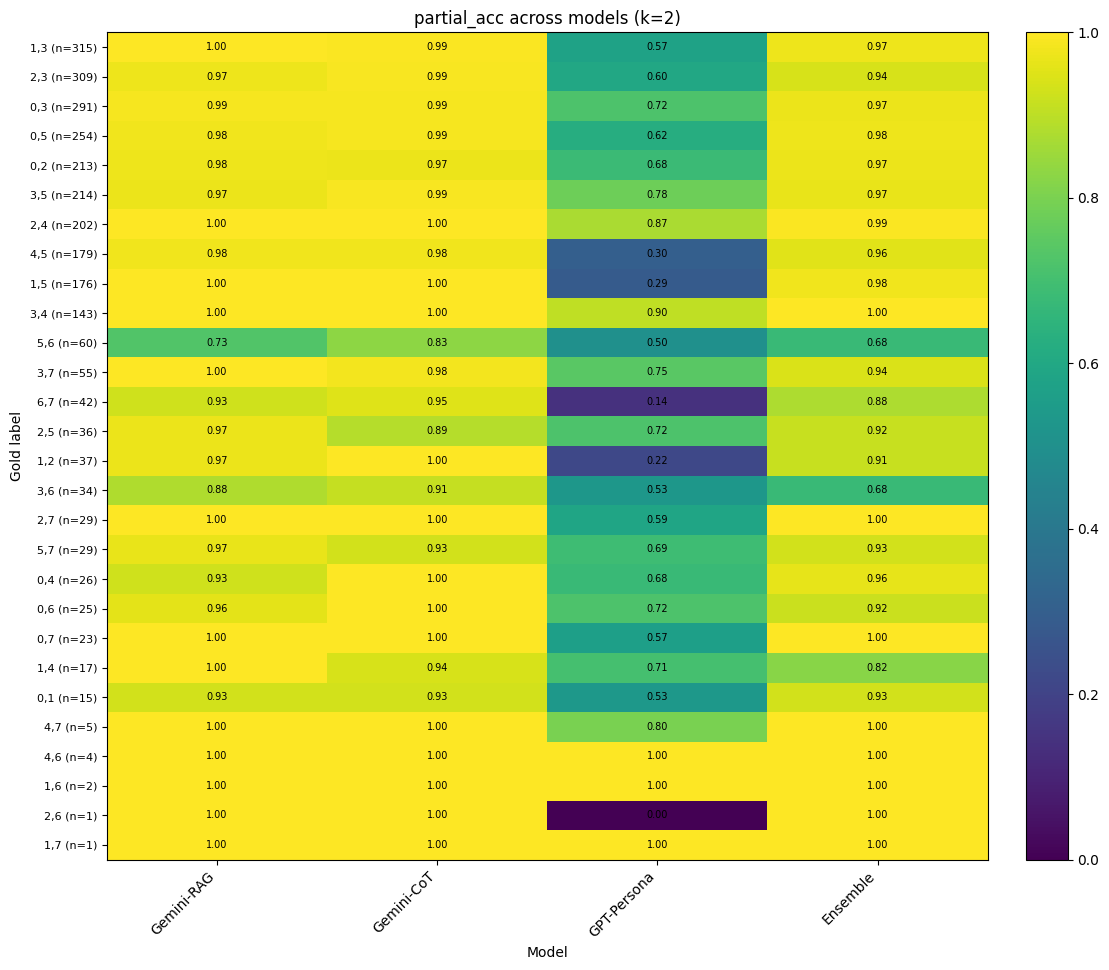

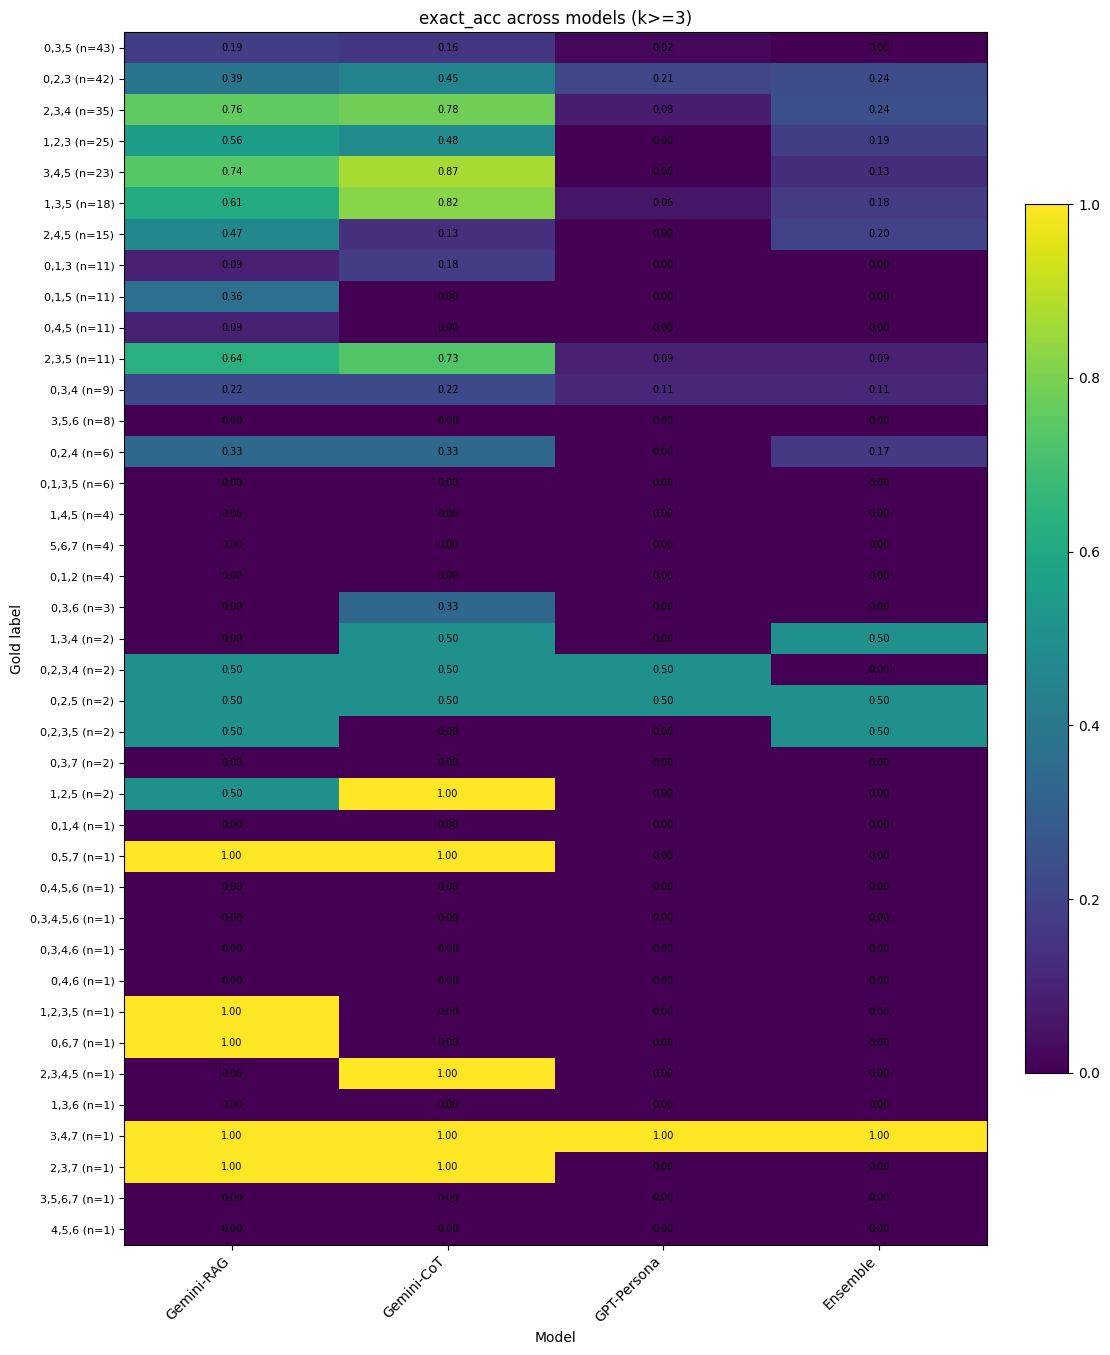

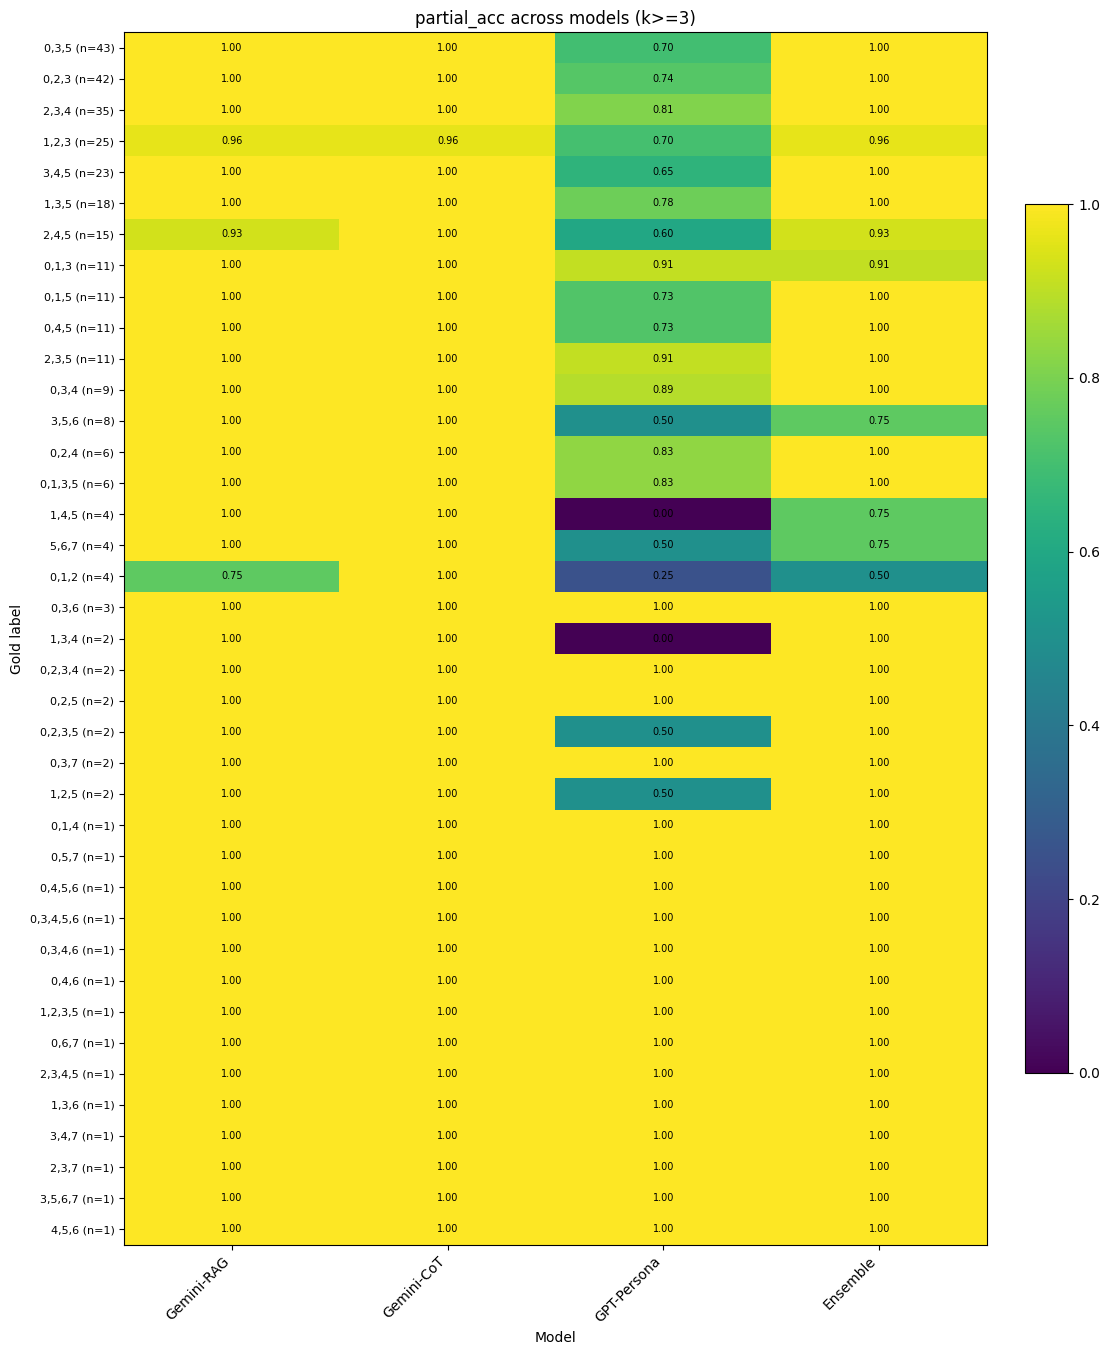

In [ ]:
# ============================================================
# Multi-model Gold-combo-wise analysis (k=1 / k=2 / k>=3)
# Heatmaps:
#   - Exact Acc heatmap:   rows=gold_combo, cols=models
#   - Partial Acc heatmap: rows=gold_combo, cols=models
# IMPORTANT:
#   - y-axis n=... uses GOLD STANDARD (DEV) combo counts ONLY
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_score, recall_score, f1_score



# =========================
# 0) Paths / Config
# =========================
DEV_PATH = "/KOR_hatespeech_all_dev.csv" # Changed path
PRED_PATHS = [
    "/gemini2.5-flash_RAG.csv",
    "/gemini2.5-flash_CoT_One.csv",
    "/gpt5.2et_Persona.csv",
    "/ensemble_result.csv"
]

GOLD_COL = "label"  # dev gold label col
PRED_COL = "label"  # pred label col

ID_CANDIDATES = ["id", "ID", "idx", "index"]
TEXT_CANDIDATES = ["comment", "comments", "text", "sentence"]

METRIC_AVERAGE = "samples"  # "micro" / "macro" / "samples" 중 선택

# =========================
# 1) Helpers
# =========================
def read_pred_file(path: str) -> pd.DataFrame:
    # supports sep=";" files
    try:
        return pd.read_table(path, sep=";")
    except Exception:
        return pd.read_csv(path)


def find_first_existing_col(df: pd.DataFrame, candidates) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None


def parse_label_set(x):
    """
    "2,3" -> {2,3}
    "3" -> {3}
    NaN/"" -> set()
    Robust to weird tokens like "label:3"
    """
    if pd.isna(x):
        return set()
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return set()

    parts = [p.strip() for p in s.split(",") if p.strip() != ""]
    out = set()
    for p in parts:
        try:
            out.add(int(p))
        except ValueError:
            digits = "".join(ch for ch in p if ch.isdigit())
            if digits != "":
                out.add(int(digits))
    return out


def canon_label_str(label_set):
    """{1,3} -> '1,3', empty -> '∅'"""
    if not label_set:
        return "-1"
    return ",".join(map(str, sorted(label_set)))


def combo_len(combo_str: str) -> int:
    """'1,2,3' -> 3, '∅' -> 0"""
    if combo_str == "-1":
        return 0
    return len(combo_str.split(","))


def _filter_by_k(df: pd.DataFrame, group_k):
    if group_k == 1:
        return df[df["k"] == 1].copy()
    elif group_k == 2:
        return df[df["k"] == 2].copy()
    else:
        return df[df["k"] >= 3].copy()


# =========================
# 2) Metrics
# =========================
def exact_match(gold_set, pred_set) -> int:
    return int(gold_set == pred_set)


def partial_match_custom(gold_set, pred_set) -> int:
    """
    Custom partial match:
    1) exact match
    2) pred ⊆ gold and at least one overlap
    3) overlap >= ceil(|gold| / 2)
    4) gold ⊆ inter or pred ⊆ inter
    """
    if not gold_set or not pred_set:
        return 0

    inter = gold_set & pred_set

    if pred_set == gold_set:
        return 1

    if len(pred_set) <= len(gold_set) and len(inter) >= 1:
        return 1

    if len(inter) >= math.ceil(len(gold_set) / 2):
        return 1

    if  gold_set & inter == gold_set or pred_set & inter == pred_set:
        print(">>>>",gold_set, pred_set, inter)
        return 1

    return 0


# =========================
# 3) Align dev & pred
# =========================
def align_dev_pred(dev_df: pd.DataFrame, pred_df: pd.DataFrame):
    """
    Priority:
      1) shared ID column
      2) shared text column
      3) fallback: index alignment (min length)
    Returns: (merged_df, how_info)
    """
    # 1) ID merge
    id_col = None
    for k in ID_CANDIDATES:
        if k in dev_df.columns and k in pred_df.columns:
            id_col = k
            break

    if id_col is not None:
        merged = dev_df.merge(pred_df, on=id_col, suffixes=("_gold", "_pred"), how="inner")
        return merged, ("id", id_col)

    # 2) text merge
    dev_text = find_first_existing_col(dev_df, TEXT_CANDIDATES)
    pred_text = find_first_existing_col(pred_df, TEXT_CANDIDATES)
    if dev_text is not None and pred_text is not None:
        d = dev_df.copy()
        p = pred_df.copy()
        d["_join_text"] = d[dev_text].astype(str)
        p["_join_text"] = p[pred_text].astype(str)
        merged = d.merge(p, on="_join_text", suffixes=("_gold", "_pred"), how="inner")
        return merged, ("text", "_join_text")

    # 3) index fallback
    min_len = min(len(dev_df), len(pred_df))
    merged = pd.concat(
        [
            dev_df.iloc[:min_len].reset_index(drop=True).add_suffix("_gold"),
            pred_df.iloc[:min_len].reset_index(drop=True).add_suffix("_pred"),
        ],
        axis=1,
    )
    return merged, ("index", None)


# =========================
# 4) Compute combo-wise metrics for one model
# =========================
def compute_combo_metrics(dev_df: pd.DataFrame, pred_df: pd.DataFrame):
    merged, how = align_dev_pred(dev_df, pred_df)

    # gold series
    if f"{GOLD_COL}_gold" in merged.columns:
        gold_series = merged[f"{GOLD_COL}_gold"]
    elif GOLD_COL in merged.columns:
        gold_series = merged[GOLD_COL]
    else:
        raise KeyError(f"Gold label column not found: {GOLD_COL} / {GOLD_COL}_gold")

    # pred series
    if f"{PRED_COL}_pred" in merged.columns:
        pred_series = merged[f"{PRED_COL}_pred"]
    elif PRED_COL in merged.columns:
        pred_series = merged[PRED_COL]
    else:
        raise KeyError(f"Pred label column not found: {PRED_COL} / {PRED_COL}_pred")

    m2 = merged.copy()
    m2["gold_set"] = gold_series.apply(parse_label_set)
    m2["pred_set"] = pred_series.apply(parse_label_set)

    # gold combo
    m2["gold_combo"] = m2["gold_set"].apply(canon_label_str)

    # exact/partial (기존 로직 유지)
    m2["exact"] = [exact_match(gs, ps) for gs, ps in zip(m2["gold_set"], m2["pred_set"])]
    m2["partial"] = [partial_match_custom(gs, ps) for gs, ps in zip(m2["gold_set"], m2["pred_set"])]

    # -------------------------
    # sklearn multilabel metrics 준비: MultiLabelBinarizer로 멀티핫 변환
    # 라벨 집합은 (gold ∪ pred) 전체에서 자동 추출
    # -------------------------
    all_labels = sorted(set().union(*m2["gold_set"].tolist(), *m2["pred_set"].tolist()))
    mlb = MultiLabelBinarizer(classes=all_labels)

    Y_true = mlb.fit_transform(m2["gold_set"])
    Y_pred = mlb.transform(m2["pred_set"])

    # -------------------------
    # gold_combo별로 sklearn metrics 계산 (정확한 정의)
    # -------------------------
    rows = []
    for combo, idx_df in m2.groupby("gold_combo").groups.items():
        idx = np.fromiter(idx_df, dtype=int)
        yt = Y_true[idx]
        yp = Y_pred[idx]

        # combo 그룹 내부에서의 multilabel precision/recall/f1
        p = precision_score(yt, yp, average=METRIC_AVERAGE, zero_division=0)
        r = recall_score(yt, yp, average=METRIC_AVERAGE, zero_division=0)
        f = f1_score(yt, yp, average=METRIC_AVERAGE, zero_division=0)

        # exact/partial도 combo별 평균
        exact_acc = m2.loc[idx, "exact"].mean()
        partial_acc = m2.loc[idx, "partial"].mean()

        rows.append({
            "gold_combo": combo,
            "support": len(idx),
            "exact_acc": exact_acc,
            "partial_acc": partial_acc,
            "precision": p,
            "recall": r,
            "f1": f
        })

    agg = pd.DataFrame(rows)
    agg["k"] = agg["gold_combo"].apply(combo_len)
    agg["partial_minus_exact"] = agg["partial_acc"] - agg["exact_acc"]

    return agg, how


# =========================
# 5) Select common combos for plotting
# =========================
def select_common_combos(agg_by_model: dict, group_k, top_n=100, strategy="sum_support"):
    """
    strategy:
      - "sum_support": rank by sum of supports across models
      - "first_model": rank by first model support
    """
    filt = {name: _filter_by_k(df, group_k) for name, df in agg_by_model.items()}

    # support table
    support_tbl = None
    for name, df in filt.items():
        s = df.set_index("gold_combo")["support"].rename(name)
        support_tbl = s.to_frame() if support_tbl is None else support_tbl.join(s, how="outer")
    support_tbl = support_tbl.fillna(0)

    if strategy == "first_model":
        first = list(filt.keys())[0]
        score = support_tbl[first]
    else:
        score = support_tbl.sum(axis=1)

    combos = score.sort_values(ascending=False).head(top_n).index.tolist()
    return combos


# =========================
# 6) Plot: ONE metric heatmap (rows=gold combos, cols=models)
#    y-axis n=... uses GOLD STANDARD support only
# =========================
def plot_metric_across_models_heatmap(
    agg_by_model: dict,
    metric_col: str,      # "exact_acc" or "partial_acc"
    group_k,
    gold_support: pd.Series,   # gold_support[gold_combo] = count in DEV
    top_n=100,
    combo_select_strategy="sum_support",
    x_label_map=None # Added optional parameter for x-axis label mapping
):
    common_combos = select_common_combos(
        agg_by_model, group_k, top_n=top_n, strategy=combo_select_strategy
    )
    model_names = list(agg_by_model.keys())

    mat = np.full((len(common_combos), len(model_names)), np.nan, dtype=float)

    for j, name in enumerate(model_names):
        df = _filter_by_k(agg_by_model[name], group_k).set_index("gold_combo")
        for i, combo in enumerate(common_combos):
            if combo in df.index:
                mat[i, j] = df.loc[combo, metric_col]

    # y-axis labels: DEV gold support only
    ylabels = [f"{c} (n={int(gold_support.get(c, 0))})" for c in common_combos]

    title_k = f"k={group_k}" if group_k in [1, 2] else "k>=3"

    plt.figure(figsize=(1.8 * len(model_names) + 4, max(6, 0.35 * len(common_combos))))
    im = plt.imshow(mat, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)

    # ★ accuracy text overlay
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if not np.isnan(val):
                plt.text(
                    j, i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=7
                )


    plt.title(f"{metric_col} across models ({title_k})")
    plt.xlabel("Model")
    plt.ylabel("Gold label")

    # Apply custom x-axis labels if x_label_map is provided
    if x_label_map:
        xlabels = [x_label_map.get(n, n) for n in model_names]
        plt.xticks(range(len(model_names)), xlabels, rotation=45, ha="right")
    else:
        plt.xticks(range(len(model_names)), model_names, rotation=45, ha="right")
    plt.yticks(range(len(ylabels)), ylabels, fontsize=8)

    plt.tight_layout()
    plt.show()


# ============================================================
# 7) Run pipeline
# ============================================================

# Load DEV
dev = pd.read_csv(DEV_PATH)

# GOLD STANDARD support (DEV only)
gold_support = (
    dev[GOLD_COL]
      .apply(parse_label_set)
      .apply(canon_label_str)
      .value_counts()
)

# Compute agg per model
agg_by_model = {}
match_info = {}

for path in PRED_PATHS:
    model_name = path.split("/")[-1].replace(".csv", "")
    pred = read_pred_file(path)

    agg, how = compute_combo_metrics(dev, pred)
    agg_by_model[model_name] = agg
    match_info[model_name] = how

print("Alignment used per model:")
for name, how in match_info.items():
    print(f" - {name}: {how}")

# Define the pretty_map for x-axis labels
pretty_map = {
    "gemini2.5-flash_RAG": "Gemini-RAG",
    "gemini2.5-flash_CoT_One": "Gemini-CoT",
    "gpt5.2et_Persona":    "GPT-Persona",
    "ensemble_result":     "Ensemble"
}

# Plot
TOP_N = 100

for k in [1, 2, ">=3"]:
    plot_metric_across_models_heatmap(
        agg_by_model,
        metric_col="exact_acc",
        group_k=k,
        gold_support=gold_support,
        top_n=TOP_N,
        combo_select_strategy="sum_support",
        x_label_map=pretty_map # Pass the map to the function
    )
    plot_metric_across_models_heatmap(
        agg_by_model,
        metric_col="partial_acc",
        group_k=k,
        gold_support=gold_support,
        top_n=TOP_N,
        combo_select_strategy="sum_support",
        x_label_map=pretty_map # Pass the map to the function
    )

# Optional: save tables
# for name, agg in agg_by_model.items():
#     agg.to_csv(f"gold_combo_metrics_{name}.csv", index=False, encoding="utf-8-sig")

## Heatmap - Precision, Recall, F1

Alignment used per model:
 - gemini2.5-flash_RAG: ('text', '_join_text')
 - gemini2.5-flash_CoT_One: ('text', '_join_text')
 - gpt5.2et_Persona: ('text', '_join_text')
 - ensemble_result: ('text', '_join_text')


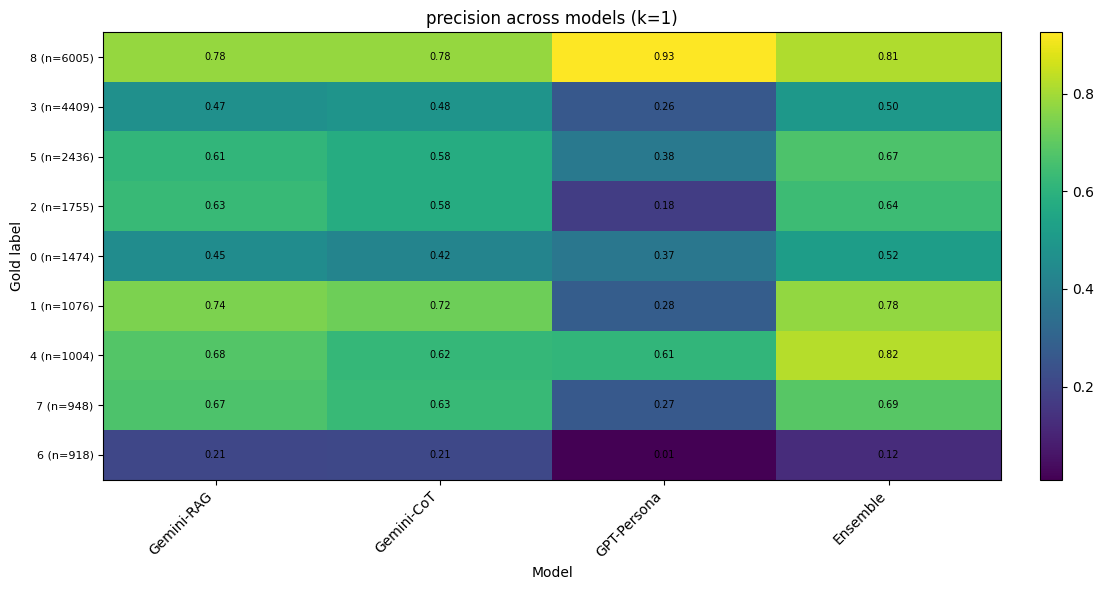

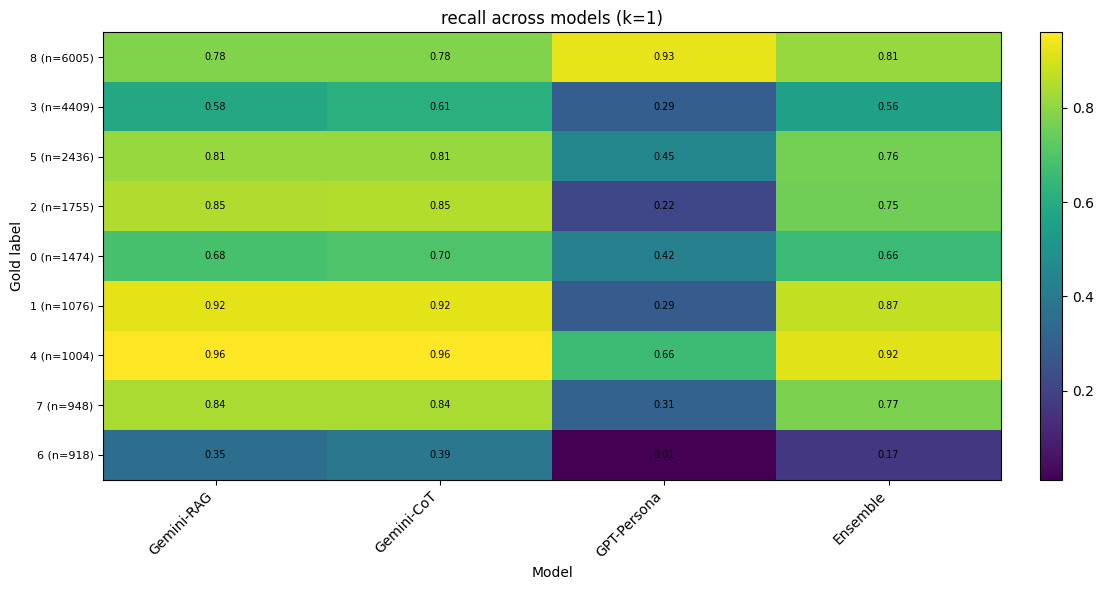

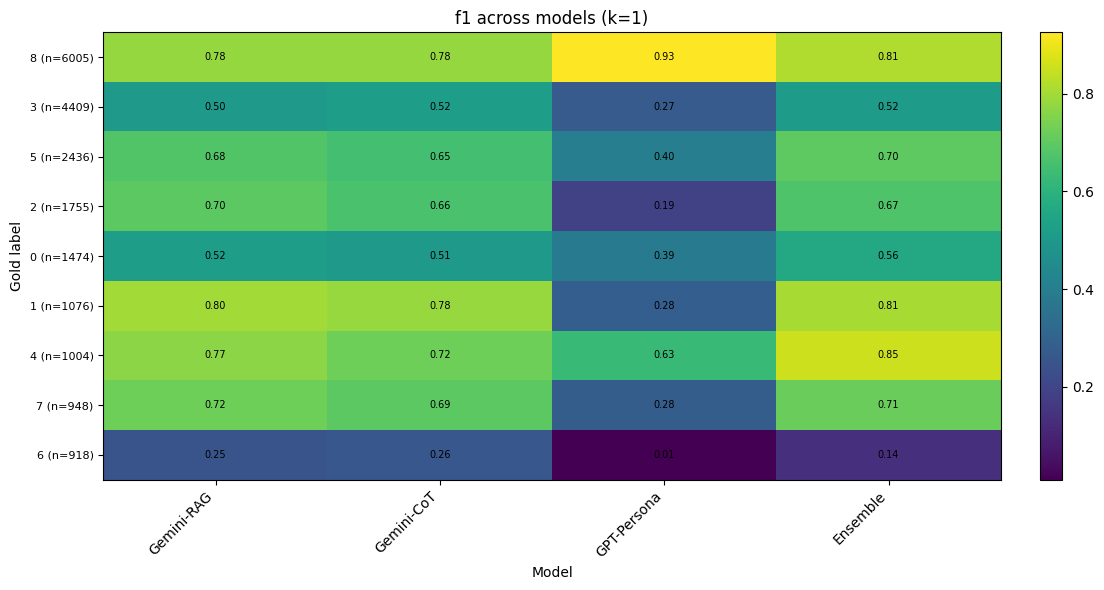

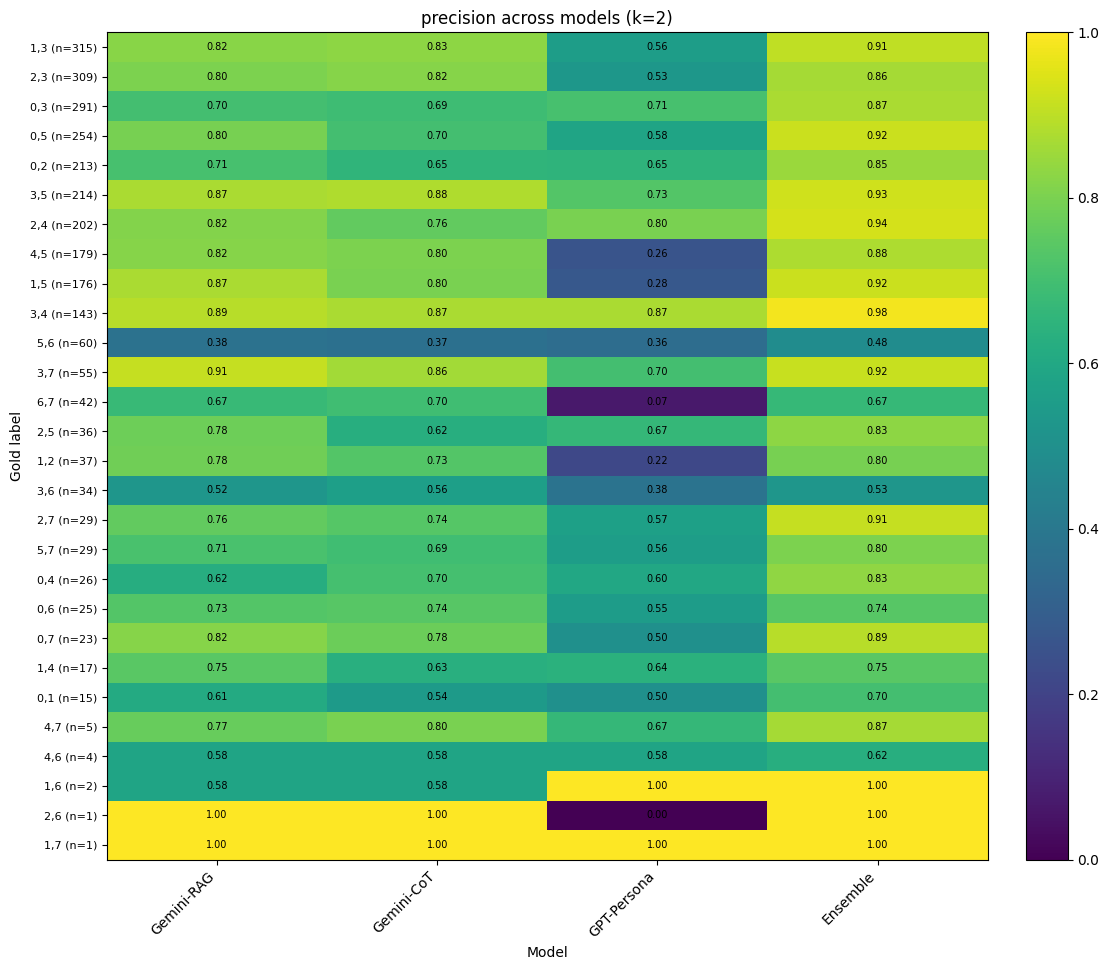

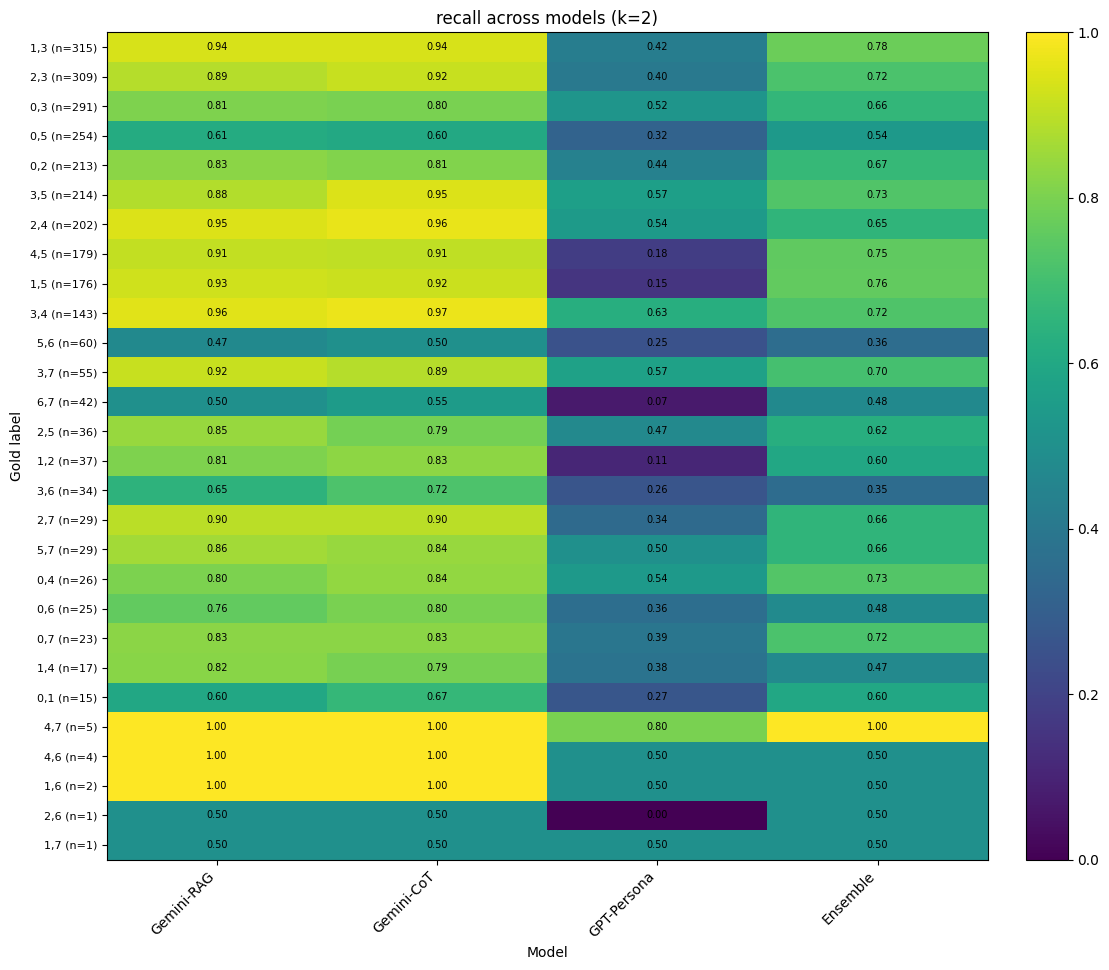

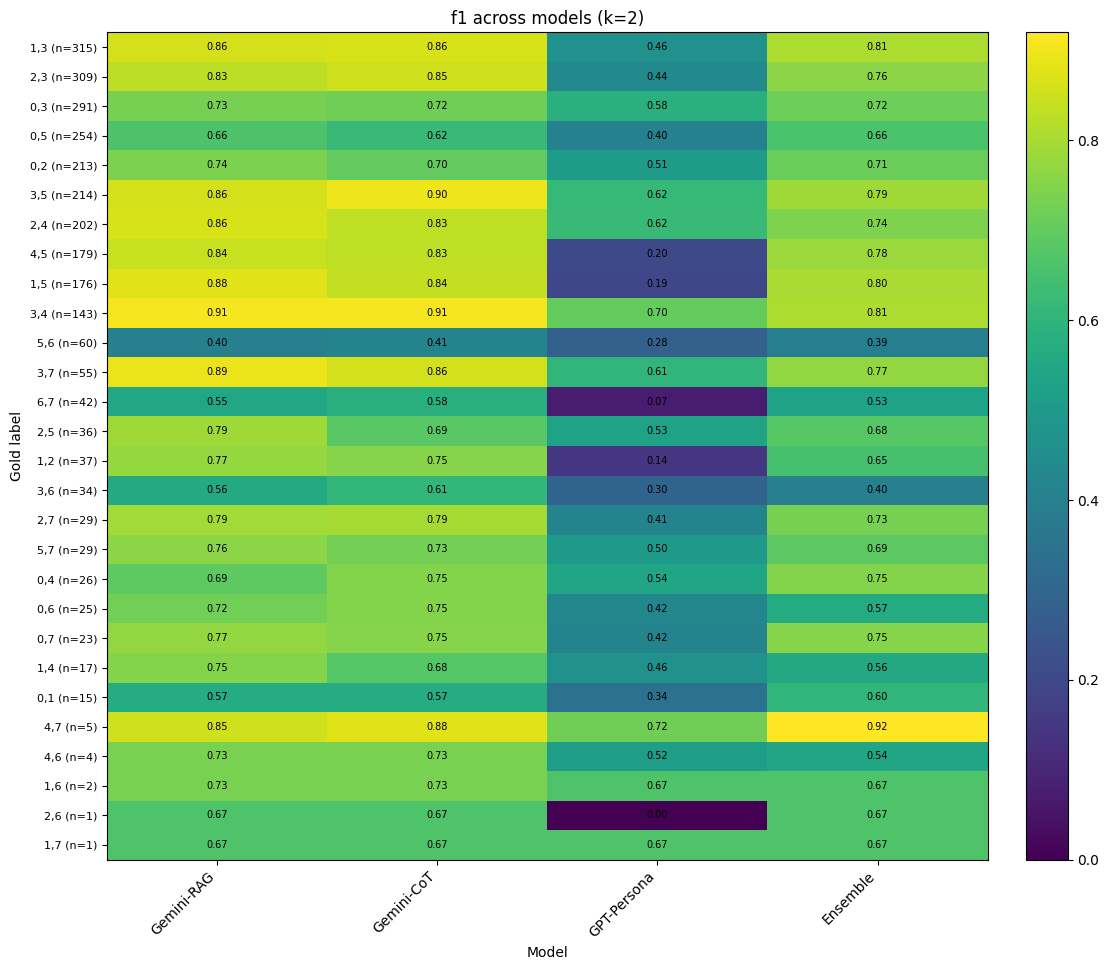

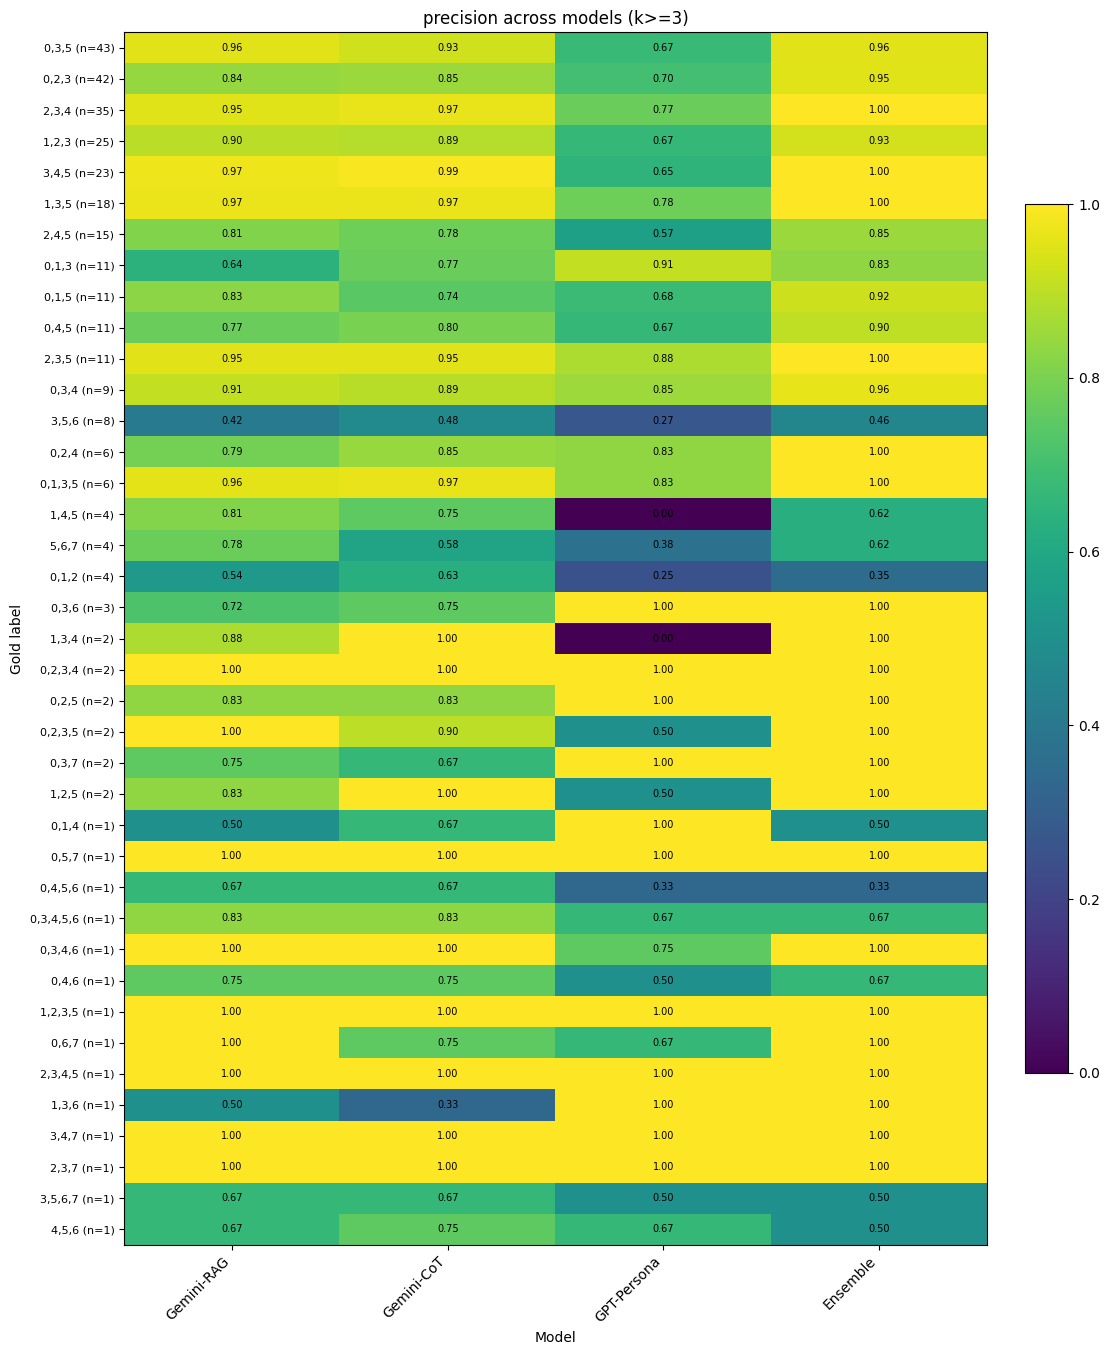

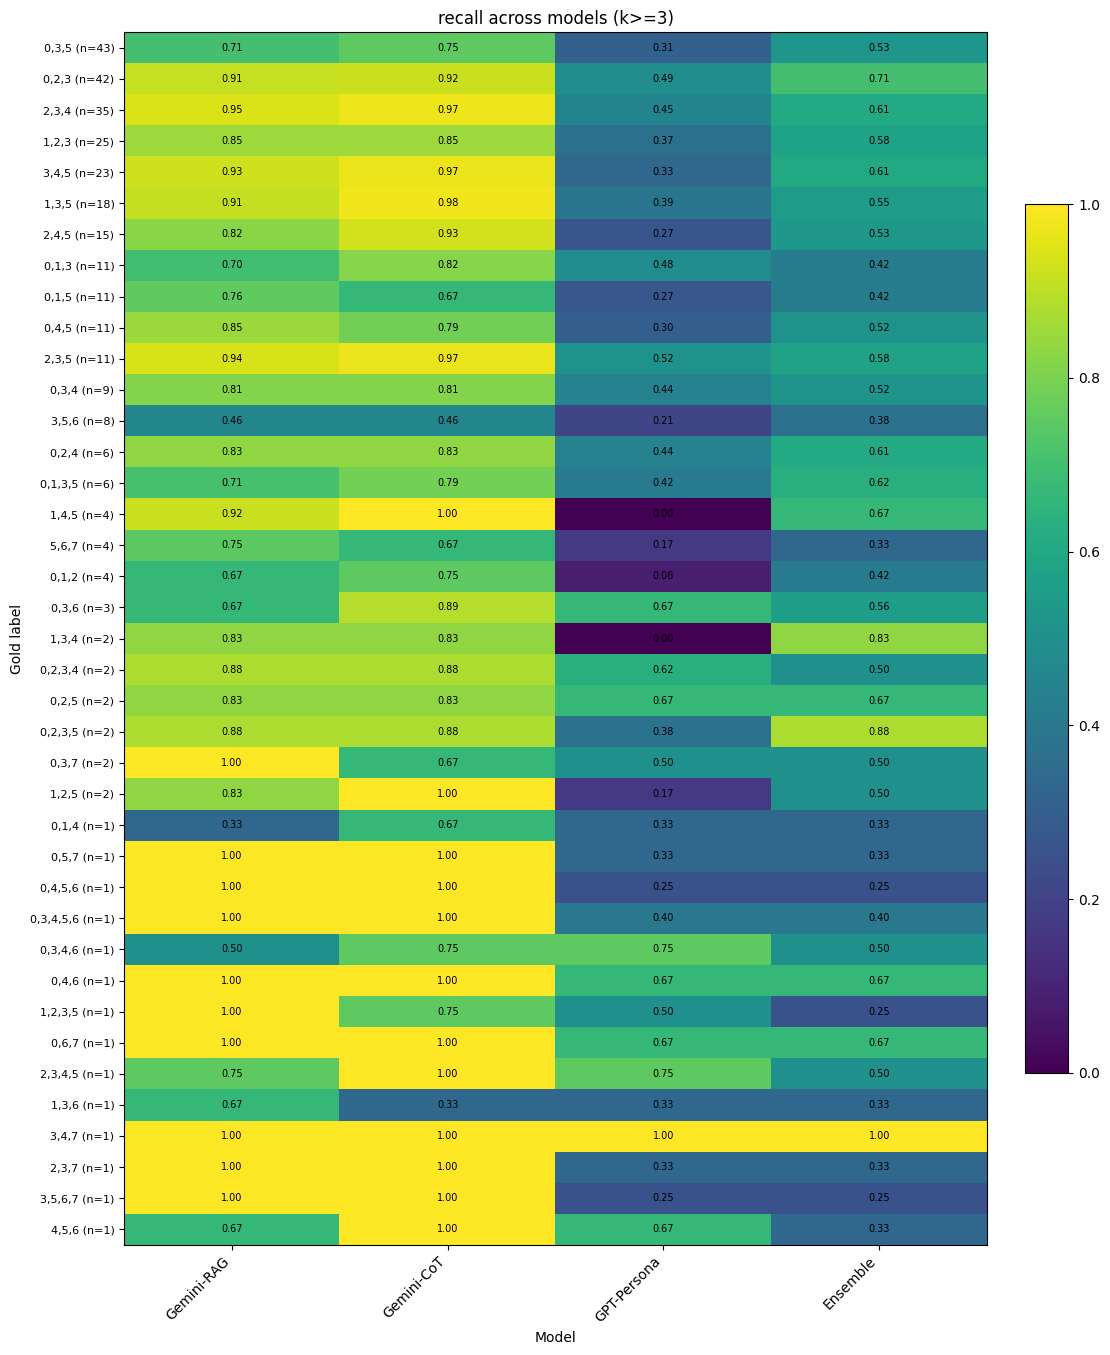

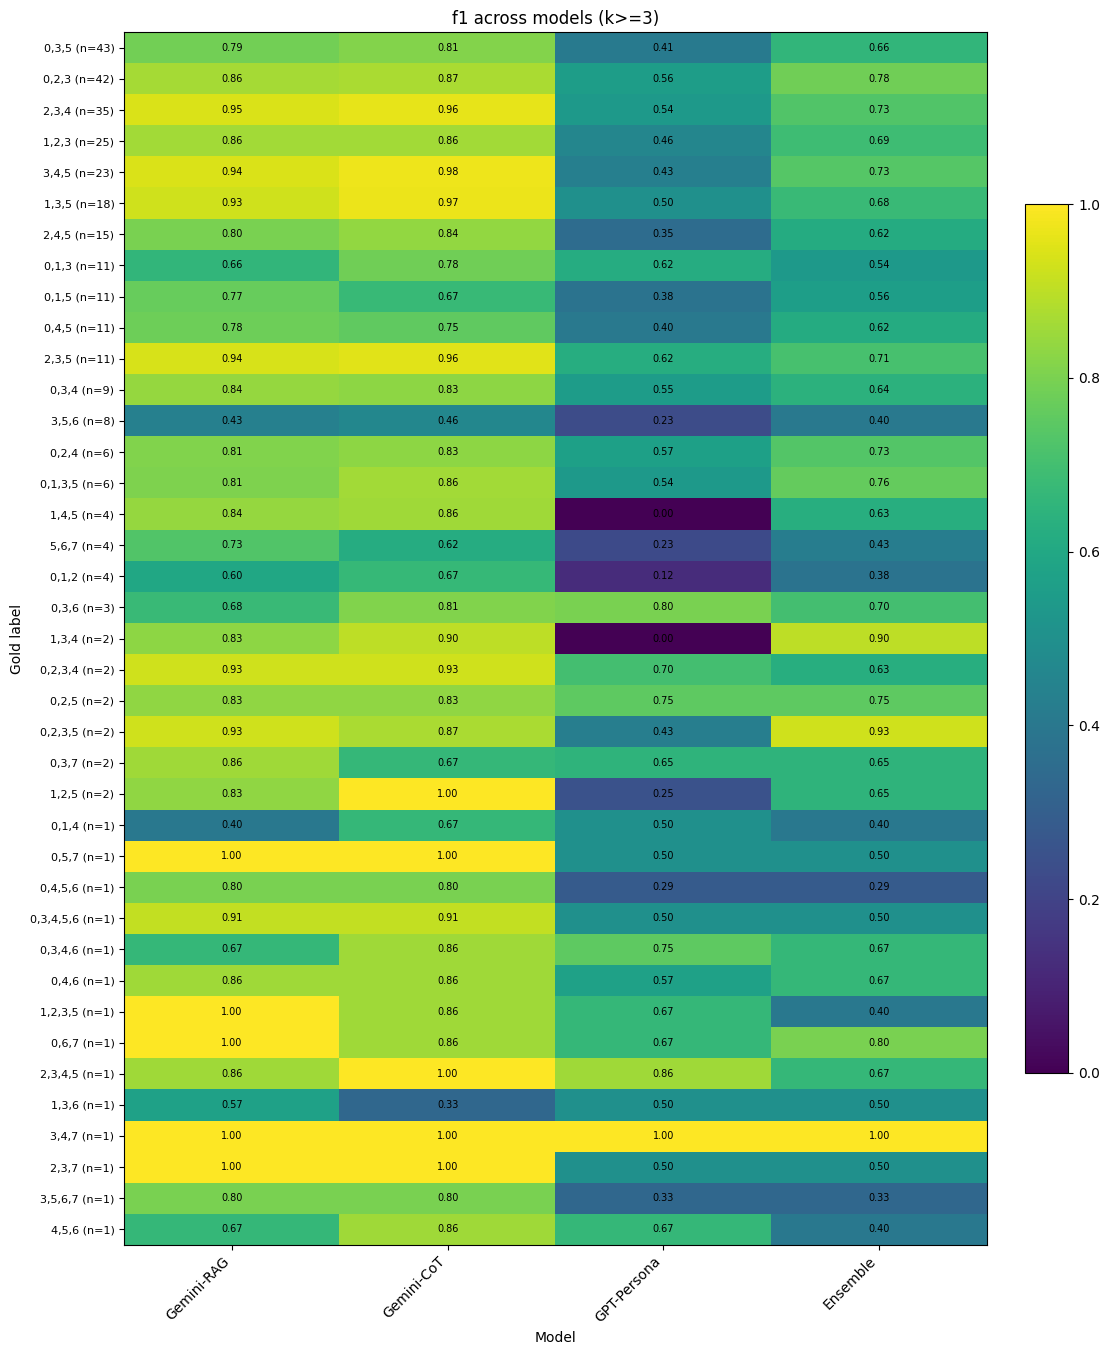

In [ ]:
# ============================================================
# Multi-model Gold-combo-wise analysis (k=1 / k=2 / k>=3)
# Heatmaps:
#   - Precision heatmap: rows=gold_combo, cols=models
#   - Recall heatmap:    rows=gold_combo, cols=models
#   - F1 heatmap:        rows=gold_combo, cols=models
# IMPORTANT:
#   - y-axis n=... uses GOLD STANDARD (DEV) combo counts ONLY
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_score, recall_score, f1_score


# =========================
# 0) Paths / Config
# =========================
DEV_PATH = "/KOR_hatespeech_all_dev.csv"
PRED_PATHS = [
    "/gemini2.5-flash_RAG.csv",
    "/gemini2.5-flash_CoT_One.csv",
    "/gpt5.2et_Persona.csv",
    "/ensemble_result.csv"
]

GOLD_COL = "label"  # dev gold label col
PRED_COL = "label"  # pred label col

ID_CANDIDATES = ["id", "ID", "idx", "index"]
TEXT_CANDIDATES = ["comment", "comments", "text", "sentence"]

METRIC_AVERAGE = "samples"  # "micro" / "macro" / "samples" 중 선택


# =========================
# 1) Helpers
# =========================
def read_pred_file(path: str) -> pd.DataFrame:
    # supports sep=";" files
    try:
        return pd.read_table(path, sep=";")
    except Exception:
        return pd.read_csv(path)


def find_first_existing_col(df: pd.DataFrame, candidates) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None


def parse_label_set(x):
    """
    "2,3" -> {2,3}
    "3" -> {3}
    NaN/"" -> set()
    Robust to weird tokens like "label:3"
    """
    if pd.isna(x):
        return set()
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return set()

    parts = [p.strip() for p in s.split(",") if p.strip() != ""]
    out = set()
    for p in parts:
        try:
            out.add(int(p))
        except ValueError:
            digits = "".join(ch for ch in p if ch.isdigit())
            if digits != "":
                out.add(int(digits))
    return out


def canon_label_str(label_set):
    """{1,3} -> '1,3', empty -> '-1'"""
    if not label_set:
        return "-1"
    return ",".join(map(str, sorted(label_set)))


def combo_len(combo_str: str) -> int:
    """'1,2,3' -> 3, '-1' -> 0"""
    if combo_str == "-1":
        return 0
    return len(combo_str.split(","))


def _filter_by_k(df: pd.DataFrame, group_k):
    if group_k == 1:
        return df[df["k"] == 1].copy()
    elif group_k == 2:
        return df[df["k"] == 2].copy()
    else:
        return df[df["k"] >= 3].copy()


# =========================
# 2) Align dev & pred
# =========================
def align_dev_pred(dev_df: pd.DataFrame, pred_df: pd.DataFrame):
    """
    Priority:
      1) shared ID column
      2) shared text column
      3) fallback: index alignment (min length)
    Returns: (merged_df, how_info)
    """
    # 1) ID merge
    id_col = None
    for k in ID_CANDIDATES:
        if k in dev_df.columns and k in pred_df.columns:
            id_col = k
            break

    if id_col is not None:
        merged = dev_df.merge(pred_df, on=id_col, suffixes=("_gold", "_pred"), how="inner")
        return merged, ("id", id_col)

    # 2) text merge
    dev_text = find_first_existing_col(dev_df, TEXT_CANDIDATES)
    pred_text = find_first_existing_col(pred_df, TEXT_CANDIDATES)
    if dev_text is not None and pred_text is not None:
        d = dev_df.copy()
        p = pred_df.copy()
        d["_join_text"] = d[dev_text].astype(str)
        p["_join_text"] = p[pred_text].astype(str)
        merged = d.merge(p, on="_join_text", suffixes=("_gold", "_pred"), how="inner")
        return merged, ("text", "_join_text")

    # 3) index fallback
    min_len = min(len(dev_df), len(pred_df))
    merged = pd.concat(
        [
            dev_df.iloc[:min_len].reset_index(drop=True).add_suffix("_gold"),
            pred_df.iloc[:min_len].reset_index(drop=True).add_suffix("_pred"),
        ],
        axis=1,
    )
    return merged, ("index", None)


# =========================
# 3) Compute combo-wise metrics for one model
# =========================
def compute_combo_metrics(dev_df: pd.DataFrame, pred_df: pd.DataFrame):
    merged, how = align_dev_pred(dev_df, pred_df)

    # gold series
    if f"{GOLD_COL}_gold" in merged.columns:
        gold_series = merged[f"{GOLD_COL}_gold"]
    elif GOLD_COL in merged.columns:
        gold_series = merged[GOLD_COL]
    else:
        raise KeyError(f"Gold label column not found: {GOLD_COL} / {GOLD_COL}_gold")

    # pred series
    if f"{PRED_COL}_pred" in merged.columns:
        pred_series = merged[f"{PRED_COL}_pred"]
    elif PRED_COL in merged.columns:
        pred_series = merged[PRED_COL]
    else:
        raise KeyError(f"Pred label column not found: {PRED_COL} / {PRED_COL}_pred")

    m2 = merged.copy()
    m2["gold_set"] = gold_series.apply(parse_label_set)
    m2["pred_set"] = pred_series.apply(parse_label_set)

    # gold combo
    m2["gold_combo"] = m2["gold_set"].apply(canon_label_str)

    # -------------------------
    # sklearn multilabel metrics 준비: MultiLabelBinarizer로 멀티핫 변환
    # 라벨 집합은 (gold ∪ pred) 전체에서 자동 추출
    # -------------------------
    all_labels = sorted(set().union(*m2["gold_set"].tolist(), *m2["pred_set"].tolist()))
    mlb = MultiLabelBinarizer(classes=all_labels)

    Y_true = mlb.fit_transform(m2["gold_set"])
    Y_pred = mlb.transform(m2["pred_set"])

    # -------------------------
    # gold_combo별로 sklearn metrics 계산
    # -------------------------
    rows = []
    for combo, idx_df in m2.groupby("gold_combo").groups.items():
        idx = np.fromiter(idx_df, dtype=int)
        yt = Y_true[idx]
        yp = Y_pred[idx]

        p = precision_score(yt, yp, average=METRIC_AVERAGE, zero_division=0)
        r = recall_score(yt, yp, average=METRIC_AVERAGE, zero_division=0)
        f = f1_score(yt, yp, average=METRIC_AVERAGE, zero_division=0)

        rows.append({
            "gold_combo": combo,
            "support": len(idx),
            "precision": p,
            "recall": r,
            "f1": f
        })

    agg = pd.DataFrame(rows)
    agg["k"] = agg["gold_combo"].apply(combo_len)

    return agg, how


# =========================
# 4) Select common combos for plotting
# =========================
def select_common_combos(agg_by_model: dict, group_k, top_n=100, strategy="sum_support"):
    """
    strategy:
      - "sum_support": rank by sum of supports across models
      - "first_model": rank by first model support
    """
    filt = {name: _filter_by_k(df, group_k) for name, df in agg_by_model.items()}

    support_tbl = None
    for name, df in filt.items():
        s = df.set_index("gold_combo")["support"].rename(name)
        support_tbl = s.to_frame() if support_tbl is None else support_tbl.join(s, how="outer")
    support_tbl = support_tbl.fillna(0)

    if strategy == "first_model":
        first = list(filt.keys())[0]
        score = support_tbl[first]
    else:
        score = support_tbl.sum(axis=1)

    combos = score.sort_values(ascending=False).head(top_n).index.tolist()
    return combos


# =========================
# 5) Plot: ONE metric heatmap (rows=gold combos, cols=models)
#    y-axis n=... uses GOLD STANDARD support only
# =========================
def plot_metric_across_models_heatmap(
    agg_by_model: dict,
    metric_col: str,      # "precision" / "recall" / "f1"
    group_k,
    gold_support: pd.Series,
    top_n=100,
    combo_select_strategy="sum_support",
    x_label_map=None      # ✅ x축 이름 바꾸기용
):
    common_combos = select_common_combos(
        agg_by_model, group_k, top_n=top_n, strategy=combo_select_strategy
    )
    model_names = list(agg_by_model.keys())

    mat = np.full((len(common_combos), len(model_names)), np.nan, dtype=float)

    for j, name in enumerate(model_names):
        df = _filter_by_k(agg_by_model[name], group_k).set_index("gold_combo")
        for i, combo in enumerate(common_combos):
            if combo in df.index:
                mat[i, j] = df.loc[combo, metric_col]

    # y-axis labels: DEV gold support only
    ylabels = [f"{c} (n={int(gold_support.get(c, 0))})" for c in common_combos]

    title_k = f"k={group_k}" if group_k in [1, 2] else "k>=3"

    plt.figure(figsize=(1.8 * len(model_names) + 4, max(6, 0.35 * len(common_combos))))
    im = plt.imshow(mat, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)

    # metric text overlay
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.2f}", ha="center", va="center", color="black", fontsize=7)

    plt.title(f"{metric_col} across models ({title_k})")
    plt.xlabel("Model")
    plt.ylabel("Gold label")

    # ✅ x축 라벨 매핑 적용
    if x_label_map is not None:
        xlabels = [x_label_map.get(n, n) for n in model_names]
        plt.xticks(range(len(model_names)), xlabels, rotation=45, ha="right")
    else:
        plt.xticks(range(len(model_names)), model_names, rotation=45, ha="right")

    plt.yticks(range(len(ylabels)), ylabels, fontsize=8)

    plt.tight_layout()
    plt.show()


# ============================================================
# 6) Run pipeline
# ============================================================

# Load DEV
dev = pd.read_csv(DEV_PATH)

# GOLD STANDARD support (DEV only)
gold_support = (
    dev[GOLD_COL]
      .apply(parse_label_set)
      .apply(canon_label_str)
      .value_counts()
)

# Compute agg per model
agg_by_model = {}
match_info = {}

for path in PRED_PATHS:
    model_name = path.split("/")[-1].replace(".csv", "")
    pred = read_pred_file(path)

    agg, how = compute_combo_metrics(dev, pred)
    agg_by_model[model_name] = agg
    match_info[model_name] = how

print("Alignment used per model:")
for name, how in match_info.items():
    print(f" - {name}: {how}")

# ✅ x축 표시 이름 바꾸기 (필요한 것만 매핑하면 됨)
pretty_map = {
    "gemini2.5-flash_RAG": "Gemini-RAG",
    "gemini2.5-flash_CoT_One": "Gemini-CoT",
    "gpt5.2et_Persona":    "GPT-Persona",
    "ensemble_result":     "Ensemble",
}

TOP_N = 100

for k in [1, 2, ">=3"]:
    for metric in ["precision", "recall", "f1"]:
        plot_metric_across_models_heatmap(
            agg_by_model,
            metric_col=metric,
            group_k=k,
            gold_support=gold_support,
            top_n=TOP_N,
            combo_select_strategy="sum_support",
            x_label_map=pretty_map
        )